<div text-align="center">
  <img src="https://raw.githubusercontent.com/FarnoushRJ/MambaLRP/main/assets/MambaLRP_logo.jpeg" width="1000"/>
</div>


<div text-align="center"><h1>🐍 MambaLRP is here! 🎉</h1>

Clone the repository and install MambaLRP.

In [1]:
# Cell 1: Clone
!git clone https://github.com/AdamBosch/MambaLRP.git || echo "Already cloned"

fatal: destination path 'MambaLRP' already exists and is not an empty directory.
Already cloned


In [2]:
# Cell 5: Install MambaLRP
!pip install ./MambaLRP --no-deps -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
import torch
print(torch.__version__)       # should be 2.1.0+cu118
import causal_conv1d
import mamba_ssm
print("All imports OK")

2.2.2+cu118
All imports OK


In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import sys

from mamba_lrp.model.mamba_huggingface import ModifiedMambaForCausalLM
from mamba_lrp.model.utils import *
from mamba_lrp.lrp.utils import relevance_propagation, vision_relevance_propagation
from mamba_lrp.dataset.general_dataset import get_imagenet_dataset
import torch
import numpy as np

In [5]:
!git clone https://github.com/hustvl/Vim.git || "Already Cloned"

fatal: destination path 'Vim' already exists and is not an empty directory.
/usr/bin/sh: 1: Already Cloned: not found


In [6]:
sys.path.append("/home/jovyan/Vim")

from mamba_ssm.ops.triton.layer_norm import RMSNorm
import vim.models_mamba as vm
import mamba_lrp.model.vision_mamba as lrp_vm

vm.RMSNorm = RMSNorm
lrp_vm.RMSNorm = RMSNorm

In [7]:
from vim.models_mamba import (
    vim_small_patch16_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2
)

# model = vim_small_patch16_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2(
#     pretrained=False,
#     fused_add_norm=False,
#     residual_in_fp32=False
# )

from vim.models_mamba import VisionMamba

model = VisionMamba(
    patch_size=16,
    embed_dim=384,
    depth=24,

    rms_norm=True,

    fused_add_norm=False,
    residual_in_fp32=False,

    final_pool_type='mean',
    if_abs_pos_embed=True,
    if_rope=False,
    if_rope_residual=False,

    bimamba_type="v2",

    if_cls_token=True,
    if_divide_out=True,
    use_middle_cls_token=True,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device).eval()

from huggingface_hub import hf_hub_download
ckpt_path = hf_hub_download(repo_id="hustvl/Vim-small-midclstok", filename="vim_s_midclstok_80p5acc.pth")
checkpoint = torch.load(ckpt_path, map_location="cpu")

state_dict = checkpoint.get("model", checkpoint)
missing, unexpected = model.load_state_dict(state_dict, strict=True)

print("missing:", missing)
print("unexpected:", unexpected)



missing: []
unexpected: []


In [8]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize(248),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
from huggingface_hub import login
login("huggingface_token") 

In [10]:
validation_dataset = get_imagenet_dataset(
    transform=transform,
    split="validation",
    max_samples=None,
    n_classes=1000
)

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

In [11]:
x = validation_dataset[0]["pixel_values"].unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    probs = logits.softmax(-1)

print("max prob:", probs.max().item())
print("pred:", logits.argmax(-1).item())

max prob: 0.8863009214401245
pred: 91


In [12]:
correct = 0
num_test = 50

for i in range(num_test):
    sample = validation_dataset[i]
    pv = sample["pixel_values"].unsqueeze(0).to(device)
    y = sample["label"]

    with torch.no_grad():
        patches = model.patch_embed(pv)   # raw patches only
        token_pos = torch.tensor([patches.shape[1] // 2]).to(device)

        pred = model(pv).argmax(-1).item()

    correct += int(pred == y)

print("Top-1:", correct / num_test)

Top-1: 0.88


In [13]:
from mamba_lrp.model.vision_mamba import ModifiedVisionMamba

for block in model.layers:
    if not hasattr(block.mixer, "if_devide_out"):
        block.mixer.if_devide_out = block.mixer.if_divide_out

modified_model = ModifiedVisionMamba(model, zero_bias=False)
modified_model = modified_model.to(device)
modified_model.eval()
print("modified_model created successfully")

modified_model created successfully


In [14]:
correct = 0
num_test = 50

for i in range(num_test):
    sample = validation_dataset[i]
    pv = sample["pixel_values"].unsqueeze(0).to(device)
    y = sample["label"]

    with torch.no_grad():
        patches = model.patch_embed(pv)        # [1, 196, 384]
        B, M, _ = patches.shape
        token_pos_val = M // 2                 # 98
        cls_token = modified_model.cls_token.expand(B, -1, -1)
        full_embeddings = torch.cat(
            (patches[:, :token_pos_val, :], cls_token, patches[:, token_pos_val:, :]), dim=1
        ) + modified_model.pos_embed           # [1, 197, 384]
        token_position = torch.tensor([token_pos_val]).to(device)

        pred = modified_model(full_embeddings, token_position=token_position).argmax(-1).item()

    correct += int(pred == y)

print("Top-1:", correct / num_test)

Top-1: 0.88


## Load model

Load model and tokenizer.

In [15]:
import torch
import gc

# 1. Delete the variables holding the references
# Note: Ensure you are actually deleting the correct names
if 'R' in locals(): del R
if 'attr' in locals(): del attr
if 'embeddings' in locals(): del embeddings
if 'morf_probs' in locals(): del morf_probs

# 2. Force Python to clear unused references from RAM
gc.collect()

# 3. Force PyTorch to release its internal cache back to the OS
torch.cuda.empty_cache()

# 4. Optional: Check how much is actually used vs reserved
print(f"Actually Used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved (Cached): {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

Actually Used: 0.11 GB
Reserved (Cached): 0.36 GB


## Load dataset

Load SST-2 dataset.

## Generate explanation

Generate explanation for one sample.

In [16]:
i = 410
sample = validation_dataset[i]
pixel_values = sample["pixel_values"].unsqueeze(0).to(device)
label = torch.tensor(sample["label"]).long().to(device)

# Raw patches — vision_relevance_propagation inserts CLS and adds pos_embed internally
with torch.no_grad():
    patches = model.patch_embed(pixel_values)  # [1, 196, 384]

R, prediction, logits = vision_relevance_propagation(
    model=modified_model,
    embeddings=patches,
    targets=label,
    n_classes=1000,
    params_to_detach=['A', 'B', 'C'],
)
print("Predicted:", prediction.item(), "| True:", label.item())


Predicted: 250 | True: 250


In [17]:
with torch.no_grad():
    out = model(pixel_values)
    probs = torch.nn.functional.softmax(out, dim=-1)
    conf, pred = torch.max(probs, dim=-1)
    print(f"Prediction: {pred.item()}, Confidence: {conf.item():.4f}")
    print(f"True Label: {sample['label']}")

Prediction: 250, Confidence: 0.6988
True Label: 250


In [18]:
# Sanity check: modified_model with full embeddings should match original model
with torch.no_grad():
    patches_sc = model.patch_embed(pixel_values)
    B, M, _ = patches_sc.shape
    token_pos_val = M // 2
    cls_token = modified_model.cls_token.expand(B, -1, -1)
    full_embeddings_sc = torch.cat(
        (patches_sc[:, :token_pos_val, :], cls_token, patches_sc[:, token_pos_val:, :]), dim=1
    ) + modified_model.pos_embed
    token_position_sc = torch.tensor([token_pos_val]).to(device)
    out_mod = modified_model(full_embeddings_sc, token_position=token_position_sc)
    out_orig = model(pixel_values)
    print("modified_model predicted label:", out_mod.squeeze().argmax().item())
    print("original model predicted label:", out_orig.squeeze().argmax().item())
    print("True label:", sample['label'])


modified_model predicted label: 250
original model predicted label: 250
True label: 250


## Visualization

For simplicity, we use the visualization utilities in Captum to display the results.

In [19]:
from captum.attr import visualization as viz

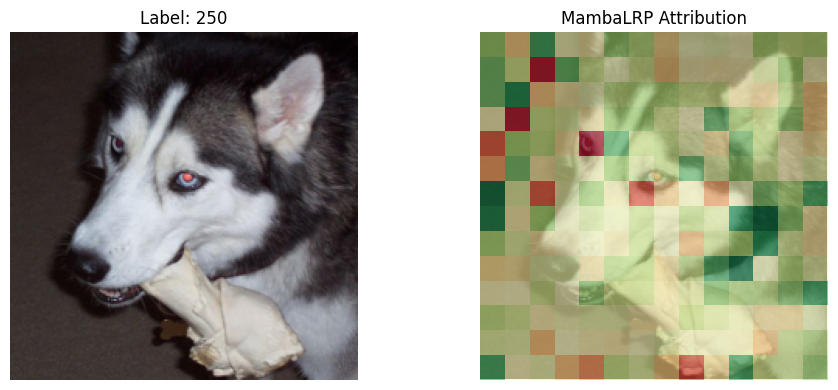

In [20]:
import matplotlib.pyplot as plt
import numpy as np

attr = R[0]
if isinstance(attr, np.ndarray):
    attr = torch.from_numpy(attr)

# CLS is at index 98 (middle), not index 0
token_pos_val = 98
patch_attrs = torch.cat([attr[:token_pos_val], attr[token_pos_val+1:]]).cpu().float().numpy()

# Robust clip for outliers
mean_a, std_a = patch_attrs.mean(), patch_attrs.std()
patch_attrs = np.clip(patch_attrs, mean_a - 3*std_a, mean_a + 3*std_a)
heatmap = patch_attrs.reshape(14, 14)

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
original_image = (sample["pixel_values"] * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()

vmax = np.abs(heatmap).max()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(original_image)
axes[0].set_title(f"Label: {label.item()}")
axes[0].axis("off")

axes[1].imshow(original_image)
axes[1].imshow(heatmap, cmap="RdYlGn", alpha=0.6,
               vmin=-vmax, vmax=vmax,
               extent=[0, 224, 224, 0], interpolation="nearest")
axes[1].set_title("MambaLRP Attribution")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [21]:
print("attr shape:", attr.shape)
print("attr[97:100]:", attr[97:100])   # values around the CLS slot
print("max relevance index:", attr.abs().argmax().item())
print("patch_attrs min/max:", patch_attrs.min(), patch_attrs.max())
print("heatmap row means:", heatmap.mean(axis=1).round(3))

attr shape: torch.Size([197])
attr[97:100]: tensor([ 0.0463, -0.0715,  0.0609])
max relevance index: 43
patch_attrs min/max: -0.06278226 0.067160964
heatmap row means: [0.011 0.004 0.011 0.008 0.003 0.011 0.005 0.02  0.007 0.012 0.016 0.003
 0.    0.004]


In [22]:
def get_vim_embeddings(model, modified_model, pixel_values, device):
    """Build full [1, 197, 384] embeddings with CLS inserted at the middle (pos 98),
    matching use_middle_cls_token=True. Positional embeddings are from modified_model."""
    x = model.patch_embed(pixel_values)                          # [B, 196, 384]
    B, M, D = x.shape
    token_pos_val = M // 2                                        # 98
    cls_token = modified_model.cls_token.expand(B, -1, -1)       # [B, 1, 384]
    # Insert CLS at the midpoint, not position 0
    x = torch.cat(
        (x[:, :token_pos_val, :], cls_token, x[:, token_pos_val:, :]), dim=1
    )                                                              # [B, 197, 384]
    x = x + modified_model.pos_embed
    return x, token_pos_val

# Build full embeddings for sample i=400
full_embeddings, token_pos_val = get_vim_embeddings(model, modified_model, pixel_values, device)
token_position = torch.tensor([token_pos_val]).to(device)


In [23]:
# R[0] has shape [197]: 196 patch tokens + 1 CLS at index token_pos_val (98)
attr_full = torch.from_numpy(R[0]) if isinstance(R[0], np.ndarray) else R[0].cpu()

# Exclude the CLS token; collect the 196 patch positions in full-sequence indices
patch_indices = list(range(token_pos_val)) + list(range(token_pos_val + 1, 197))
patch_relevance = attr_full[patch_indices]                        # [196]

# Most-relevant-first and least-relevant-first orderings (by absolute relevance)
# Stored as full-sequence indices so get_morf_curve_batched can use them directly
idx_morf = torch.tensor([patch_indices[j] for j in torch.argsort(patch_relevance.abs(), descending=True)])
idx_lerf = torch.tensor([patch_indices[j] for j in torch.argsort(patch_relevance.abs(), descending=False)])

print("patch_relevance shape:", patch_relevance.shape)  # [196]
print("Top-5 most relevant patch indices:", idx_morf[:5].tolist())


patch_relevance shape: torch.Size([196])
Top-5 most relevant patch indices: [43, 16, 60, 84, 110]


In [24]:
def get_morf_curve_logits(model, input_ids, sorted_indices, target_label):
    scores = []
    temp_input_ids = input_ids.clone()
    
    with torch.no_grad():
        logits = model(temp_input_ids) 
        initial_logit = logits[0, -1, target_label].item()
        scores.append(initial_logit)

    for idx in sorted_indices:
        temp_input_ids[0, idx + 1] = tokenizer.pad_token_id 
        
        with torch.no_grad():
            logits = model(temp_input_ids)
            logit = logits[0, -1, target_label].item()
            scores.append(logit)
            
    return scores
#morf_values = get_morf_curve_logits(modified_model, input_ids, sorted_indices, label.item())

In [25]:
def get_morf_curve_batched(model, embeddings, sorted_indices, target_label, token_position, chunk_size=32):
    seq_len = len(sorted_indices)
    base_embeddings = embeddings.clone().repeat(seq_len + 1, 1, 1)
    for i, idx in enumerate(sorted_indices):
        base_embeddings[i+1:, idx.item(), :] = 0.0
    all_logits = []
    with torch.no_grad():
        for i in range(0, base_embeddings.size(0), chunk_size):
            chunk = base_embeddings[i:i+chunk_size]           # already on device
            batch_token_pos = token_position.repeat(chunk.size(0))
            logits = model(chunk, token_position=batch_token_pos)
            logits = logits.reshape(chunk.size(0), -1)        # [B, 1000]
            all_logits.extend(logits[:, target_label].cpu().tolist())
    return all_logits

In [26]:
import numpy as np
from tqdm import tqdm

num_samples = 50
all_delta_afs = []
print(f"Evaluating {num_samples} samples from ImageNet...")

for i in tqdm(range(num_samples)):
    sample = validation_dataset[i]
    pixel_values = sample["pixel_values"].unsqueeze(0).to(device)

    with torch.no_grad():
        patches = model.patch_embed(pixel_values)          # [1, 196, 384] raw
        B, M, _ = patches.shape
        token_pos_val = M // 2                             # 98
        cls_token = modified_model.cls_token.expand(B, -1, -1)
        full_embeddings = torch.cat(
            (patches[:, :token_pos_val, :], cls_token, patches[:, token_pos_val:, :]), dim=1
        ) + modified_model.pos_embed                       # [1, 197, 384]
        token_position = torch.tensor([token_pos_val]).to(device)
        outputs = modified_model(full_embeddings, token_position=token_position)
        pred_label = torch.argmax(outputs.squeeze()).item()
        
    # if pred_label != sample["label"]:
    #     continue

    # LRP on raw patches — vision_relevance_propagation handles CLS + pos_embed internally
    R_i, _, _ = vision_relevance_propagation(
        model=modified_model,
        embeddings=patches,
        targets=torch.tensor(pred_label).long().to(device),
        n_classes=1000,
        params_to_detach=['A', 'B', 'C'],
    )

    attr_i = torch.from_numpy(R_i[0]) if isinstance(R_i[0], np.ndarray) else R_i[0].cpu()
    patch_indices = list(range(token_pos_val)) + list(range(token_pos_val + 1, 197))
    patch_relevance = attr_i[patch_indices]

    idx_morf = torch.tensor([patch_indices[j] for j in torch.argsort(patch_relevance.abs(), descending=True)])
    idx_lerf = torch.tensor([patch_indices[j] for j in torch.argsort(patch_relevance.abs(), descending=False)])

    morf_curve = get_morf_curve_batched(modified_model, full_embeddings, idx_morf, pred_label, token_position)
    lerf_curve = get_morf_curve_batched(modified_model, full_embeddings, idx_lerf, pred_label, token_position)

    x = np.linspace(0, 1, len(morf_curve))
    delta_af = np.trapz(lerf_curve, x) - np.trapz(morf_curve, x)
    all_delta_afs.append(delta_af)

mean_delta_af = np.mean(all_delta_afs)
print(f"\nMean Delta AF over {num_samples} samples: {mean_delta_af:.4f}")
print(f"Paper reference (Vim-S, ImageNet): 4.715")


Evaluating 50 samples from ImageNet...


100%|██████████| 50/50 [11:31<00:00, 13.84s/it]


Mean Delta AF over 50 samples: 2.1892
Paper reference (Vim-S, ImageNet): 4.715
